In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os → recorrer carpetas.
cv2 → leer imágenes.
numpy → almacenar las imágenes en arreglos.
matplotlib → mostrarlas.

Importar Dataset


In [23]:
# 1. Instalar la librería (solo la primera vez)
# pip install kagglehub

import kagglehub

# 2. Descarga el dataset (o usa la copia en caché si ya existe)
ruta_base = kagglehub.dataset_download("crowww/a-large-scale-fish-dataset")

print("Dataset descargado en:", ruta_base)

Dataset descargado en: C:\Users\fabia\.cache\kagglehub\datasets\crowww\a-large-scale-fish-dataset\versions\2


In [24]:

ruta = os.path.join(ruta_base, "Fish_Dataset", "Fish_Dataset")
print(os.listdir(ruta))

['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'license.txt', 'README.txt', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Segmentation_example_script.m', 'Shrimp', 'Striped Red Mullet', 'Trout']


Listas para imagenes y etiquetas para guardar las imagenes y nombre de pez

In [25]:
imagenes = []
etiquetas = []

In [26]:
for especie in os.listdir(ruta):  # el for recorre la lista una por una especie de pez

    carpeta_especie = os.path.join(ruta, especie)   # arma ruta completa hacia la carpeta de la especie

    if os.path.isdir(carpeta_especie):

        # Entrar a la segunda carpeta con el mismo nombre
        carpeta_imagenes = os.path.join(carpeta_especie, especie)   # para que no entre a la carpeta GT que tiene solo siluetas del pez

        if os.path.isdir(carpeta_imagenes):

            for archivo in os.listdir(carpeta_imagenes):    # recorre uno por uno cada archivo de imagen dentro de la carpeta definitiva

                ruta_imagen = os.path.join(carpeta_imagenes, archivo)

                imagen = cv2.imread(ruta_imagen)        # ruta completa, lee el archivo de imagen y lo convierte en array de numeros

                if imagen is not None:  # para precaucion por si hubiera imagenes corruptas

                    imagen = cv2.resize(imagen, (224,224)) # se redimensionan las imagenes porque venian en dimensiones diferentes y se necesitan todas de la misma dimension

                    imagenes.append(imagen)
                    etiquetas.append(especie)   # guarda imagenes y etiquetas en paralelo

Convertir a numpy

In [27]:
x = np.array(imagenes)
                        # se estructuran los datos
y = np.array(etiquetas)

Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

test_size=0.2 → 80% entrenamiento, 20% prueba.
random_state=42 → siempre obtendrás la misma división.
stratify=y → mantiene la misma proporción de especies en entrenamiento y prueba. Esto es muy recomendable cuando hay varias clases.

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x,      # imagenes
    y,      # etiquetas de especies
    test_size=0.2,      # separa 20% de los datos para test, 80% para entrenamiento
    random_state=42,    # semilla
    stratify=y      #  # mantiene la misma proporción de cada especie en train y test
)

In [30]:
x_train.shape

(7200, 224, 224, 3)

In [31]:
x_test.shape

(1800, 224, 224, 3)

In [32]:
y_train

array(['Hourse Mackerel', 'Gilt-Head Bream', 'Red Sea Bream', ...,
       'Shrimp', 'Shrimp', 'Shrimp'], shape=(7200,), dtype='<U18')

In [33]:
y_test

array(['Red Sea Bream', 'Trout', 'Shrimp', ..., 'Black Sea Sprat',
       'Red Sea Bream', 'Shrimp'], shape=(1800,), dtype='<U18')

In [34]:
print(len(imagenes))

9000


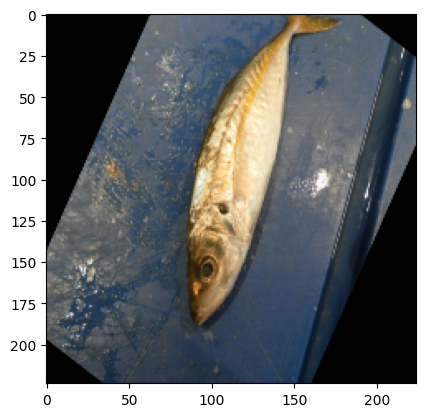

In [35]:
primera_imagen = x_train[0] # toma la primera imagen del set de entrenamiento

plt.imshow(cv2.cvtColor(primera_imagen, cv2.COLOR_BGR2RGB)) # cv2 lee las imágenes en orden BGR (Azul-Verde-Rojo), pero matplotlib espera RGB (Rojo-Verde-Azul)
# si no se hace esta conversión, los colores se ven invertidos (el azul se vería naranja, etc.)
plt.show()  # muestra la imagen en pantalla
plt.show()

In [36]:
primera_imagen.shape

(224, 224, 3)

In [37]:
from collections import Counter

Counter(y)
# cuenta cuántas veces aparece cada especie dentro del array y (etiquetas)
# sirve para verificar el balance de clases: si todas las especies tienen
# aproximadamente la misma cantidad de imágenes, el dataset está balanceado

Counter({np.str_('Black Sea Sprat'): 1000,
         np.str_('Gilt-Head Bream'): 1000,
         np.str_('Hourse Mackerel'): 1000,
         np.str_('Red Mullet'): 1000,
         np.str_('Red Sea Bream'): 1000,
         np.str_('Sea Bass'): 1000,
         np.str_('Shrimp'): 1000,
         np.str_('Striped Red Mullet'): 1000,
         np.str_('Trout'): 1000})

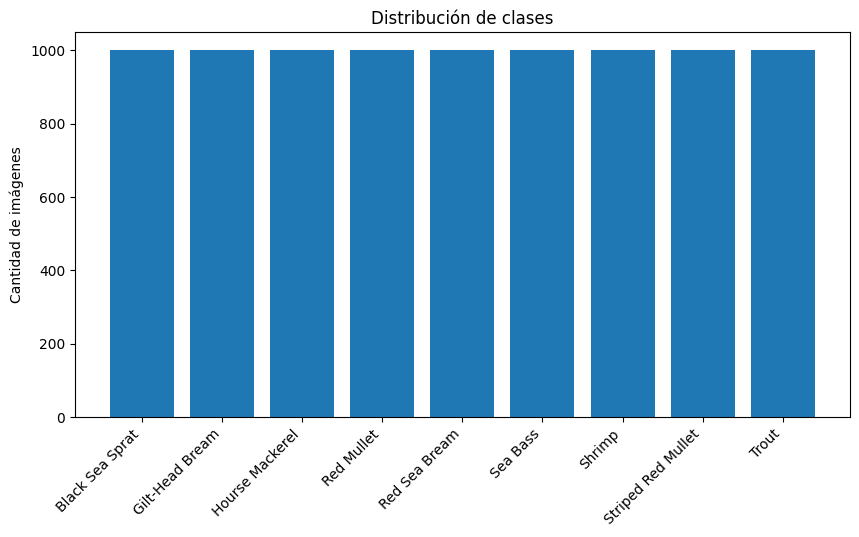

In [38]:
import matplotlib.pyplot as plt

conteo = Counter(y)
plt.figure(figsize=(10,5))
plt.bar(conteo.keys(), conteo.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases")
plt.show()

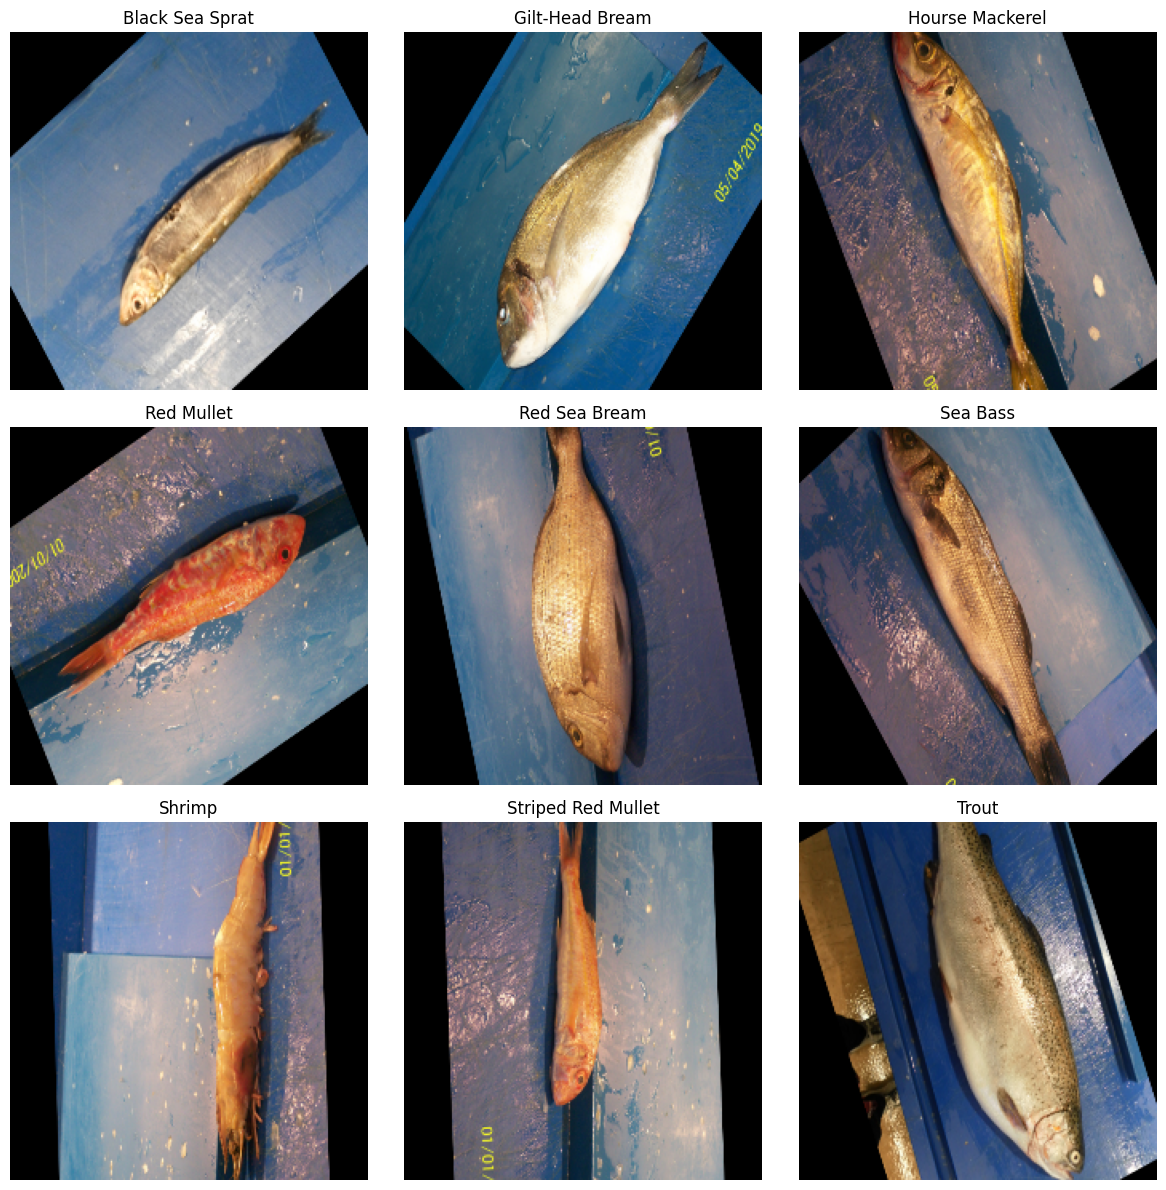

In [39]:
especies = list(conteo.keys())      # lista con el nombre de cada especie única
fig, axes = plt.subplots(3, 3, figsize=(12,12))     # crea una cuadrícula de 3x3
for ax, especie in zip(axes.ravel(), especies):     # recorre cada subgráfico
    idx = etiquetas.index(especie)       # busca la posición (índice) de la primera imagen que pertenece a esa especie
    ax.imshow(cv2.cvtColor(imagenes[idx], cv2.COLOR_BGR2RGB))       # muestra esa imagen en el subgráfico correspondiente (convertida a RGB)
    ax.set_title(especie)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [40]:
primera_imagen = x_train[0]
print(primera_imagen.shape)   # (224, 224, 3)   alto, ancho, canales de color
print(primera_imagen.max(), primera_imagen.min())  # 255, 0 (antes de escalar)
primera_imagen  # muestra el array crudo
# sale array de 0 por los bordes negros de las imagenes

(224, 224, 3)
255 0


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(224, 224, 3), dtype=uint8)

In [41]:
print("Valor promedio de la imagen:", primera_imagen.mean())
print("¿Tiene píxeles distintos de cero?", (primera_imagen > 0).any())

# Mira el centro de la imagen, donde debería estar el pez
primera_imagen[100:105, 100:105]

Valor promedio de la imagen: 78.26806308460884
¿Tiene píxeles distintos de cero? True


array([[[139, 197, 233],
        [ 89, 153, 199],
        [105, 175, 223],
        [106, 172, 220],
        [111, 177, 222]],

       [[116, 178, 222],
        [ 92, 156, 203],
        [107, 174, 221],
        [129, 195, 239],
        [139, 204, 246]],

       [[ 92, 155, 204],
        [117, 182, 230],
        [124, 190, 236],
        [158, 220, 253],
        [156, 218, 253]],

       [[ 79, 143, 193],
        [102, 170, 218],
        [115, 180, 224],
        [118, 176, 221],
        [122, 180, 225]],

       [[105, 169, 218],
        [107, 174, 223],
        [104, 166, 216],
        [ 94, 149, 198],
        [ 98, 157, 203]]], dtype=uint8)